In [2]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter
#Imports
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter
import matplotlib.pyplot as plt

#TFIM Functions

def k_vals(L):
    return (2 * np.arange(-L//2, L//2) + 1) * np.pi / (L)
def epsilon(k,g,J=1):
    """Calculates disperson from TFIM
    inputs: k (np.array), g (float), J (float)

    returns: epsilon (np.array)
    """
    return 2*J*np.sqrt( (g-np.cos(k))**2+np.sin(k)**2)

def U(k, g):
    """Returns normalized eigenvectors in k space for TFIM
    inputs: k (np.array), g (float)

    returns: [u,v] where u={uk} (np.array) and v= {vk} (np.array) are the normalized eigenvectors


    Example

    U(k,inf)[0] = u = [1 , 1 , 1....]
    """
    u = g - np.cos(k) + np.sqrt(g**2 - 2 * g * np.cos(k) + 1)
    v = np.sin(k)
    norm = np.sqrt(u**2 + v**2)
    return u / norm, v / norm

#Correlation Functions

def p_k(k,tau):
   
    
    return np.exp( -2*np.pi*tau*k**2)

def p_k(k,tau):
    delta_m = 4*tau*np.sin(k)**2

    return np.exp(-np.pi/2*delta_m)



def ca(U, k, l, tau):
    """
    Compute ⟨ c_l^† c_0 ⟩ for symmetric k-grid.

    Parameters:
    - U: tuple (u, v): Bogoliubov coefficients, np.arrays of shape (N,)
    - k: np.array of momenta, symmetric from -π to π
    - l: integer separation
    - tau: float parameter for occupation function p_k

    Returns:
    - complex: ⟨ c_l^† c_0 ⟩
    """
    u, v = U
    p = p_k(k, tau)

    # reversed arrays for -k terms
    v_neg = v[::-1]
    p_neg = p[::-1]

    amp = np.abs(u)**2 * p + np.abs(v_neg)**2 * (1 - p_neg)
    phase = np.exp(1j * k * l)

    return np.mean(amp * phase)

def ac(U, k, l, tau):
    """
    Compute ⟨ c_l c_0^† ⟩ for symmetric k-grid.

    Parameters:
    - U: tuple (u, v): Bogoliubov coefficients, np.arrays of shape (N,)
    - k: np.array of momenta, symmetric from -π to π
    - l: integer separation
    - tau: float parameter for occupation function p_k

    Returns:
    - complex: ⟨ c_l c_0^† ⟩
    """
    u, v = U
    p = p_k(k, tau)
    p_neg = p[::-1]
    v_neg = v[::-1]

    amp = np.abs(u)**2 * (1 - p) + np.abs(v_neg)**2 * p_neg
    phase = np.exp(-1j * k * l)

    return np.mean(amp * phase)

def aa(U, k, l, tau):
    """
    Compute ⟨ c_l^† c_0^† ⟩ for symmetric k-grid.

    Parameters:
    - U: tuple (u, v): Bogoliubov coefficients, np.arrays of shape (N,)
    - k: np.array of momenta, symmetric from -π to π
    - l: integer separation
    - tau: float parameter for occupation function p_k

    Returns:
    - complex: ⟨ c_l^† c_0^† ⟩
    """
    u, v = U
    p = p_k(k, tau)

    u_neg = u[::-1]
    v_neg = v[::-1]
    p_neg = p[::-1]

    amp = np.conj(u) * np.conj(v) * p + np.conj(v_neg) * np.conj(u_neg) * (1 - p_neg)
    phase = np.exp(-1j * k * l)

    return 1j* np.mean(amp * phase)
def cc(U, k, l, tau):
    """
    Compute ⟨ c_l c_0 ⟩ for symmetric k-grid.

    Parameters:
    - U: tuple (u, v): Bogoliubov coefficients, np.arrays of shape (N,)
    - k: np.array of momenta, symmetric from -π to π
    - l: integer separation
    - tau: float parameter for occupation function p_k

    Returns:
    - complex: ⟨ c_l c_0 ⟩
    """
    u, v = U
    p = p_k(k, tau)

    u_neg = u[::-1]
    v_neg = v[::-1]
    p_neg = p[::-1]

    amp = u * v * (1 - p) + v_neg * u_neg * p_neg
    phase = np.exp(-1j * k * l)

    return 1j*np.mean(amp * phase)

def AA(args):
    """input: args = [U,k,l]"""
    return cc(*args)+ca(*args)+ac(*args)+aa(*args)
def BB(args):
    """input: args = [U,k,l]"""
    return aa(*args)-ac(*args)-ca(*args)+cc(*args)
def AB(args):
    """input: args = [U,k,l]"""
    return (-aa(*args)+ac(*args)-ca(*args)+cc(*args))
def BA(args):
    """input: args = [U,k,l]"""
    return (-aa(*args)-ac(*args)+ca(*args)+cc(*args))


def D(N,U,k,tau):
    """Using Definition in 4.72 of Sachdev.
    
    N = i-j+1 but we will also set i = 0 and j=n so 
    N = 1-n"""
    n = 1-N
    args = [U,k,n,tau]
    return BA(args)

def sigma_general(indices,T,k,tau):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,T,k,tau)
    return np.linalg.det(C)



def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,U,k, tau,even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,U,k,tau)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n



def P_n_correlations(n,l,U,k, tau,even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(sigma_general(indices,U,k))*degen)
        else:
            dat.append(sigma_general(indices,U,k,tau)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [29]:
k = k_vals(1000)

Ui = U(k,0)
T= 1
args = (Ui,k,1,T)
kb.D(1,Ui,k)

kb.sigma_general([0,1],Ui,k)

np.float64(1.0)

In [133]:
[n for n in range(1,10)]

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [134]:
from tqdm import tqdm

T = np.logspace(-1,2.5,50)
dat1 = [[np.abs(kb.P_n(n,Ui,k)-P_n(n,Ui,k,t)) for t in T] for n in tqdm(range(2,8))]

  0%|          | 0/6 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_17892/852523449.py:215: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k,tau)
100%|██████████| 6/6 [00:04<00:00,  1.24it/s]


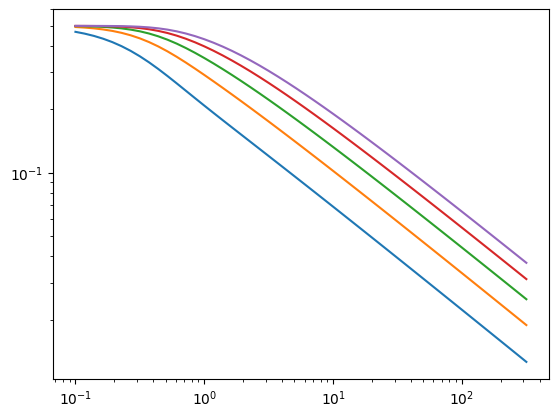

In [135]:
plt.plot(T,(np.array(dat1).T[:,1:]))
plt.yscale("log")
plt.xscale("log")


In [136]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    plt.scatter(X,dat)
    plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    plt.show()
    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law



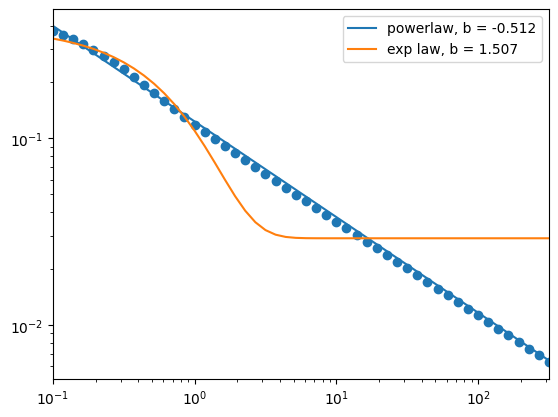

[0.0013613 0.006482 ]
[0.01324201 0.11673143 0.00357014]


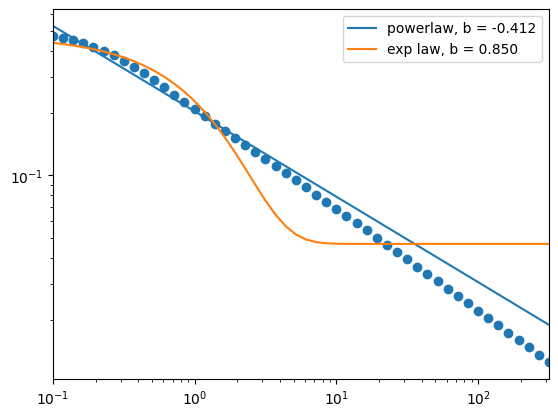

[0.0031048  0.00912676]
[0.0134125  0.06800324 0.00509575]


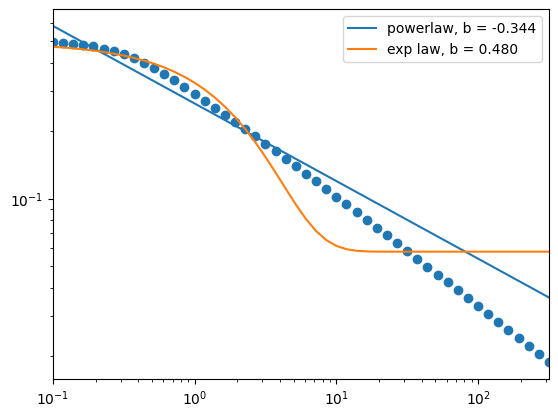

[0.00522941 0.01184559]
[0.01153332 0.03644132 0.00565119]


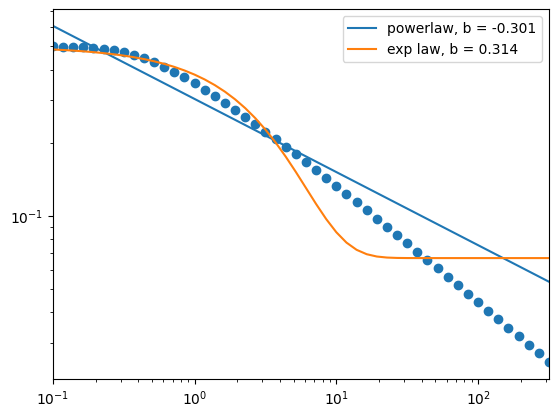

[0.00665685 0.01294731]
[0.01029464 0.02275971 0.00585473]


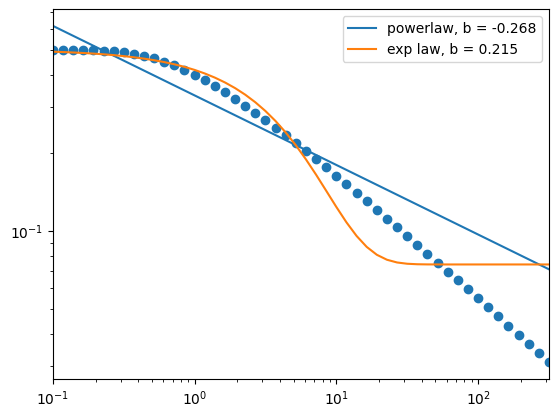

[0.00786374 0.01360931]
[0.00919552 0.01462256 0.00583943]


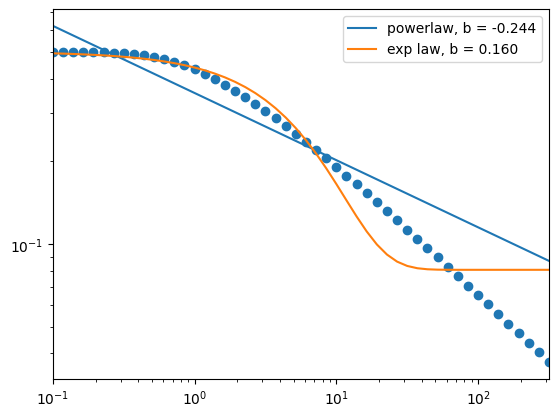

[0.00870839 0.01381412]
[0.00843861 0.01029115 0.00577627]


In [137]:
d = []
for n in range(0,6):
    X =np.abs(np.array(dat1).T[:,n])

    d+= [fit(X,T)[0][1]]



Text(0, 0.5, 'Deviation from ground state')

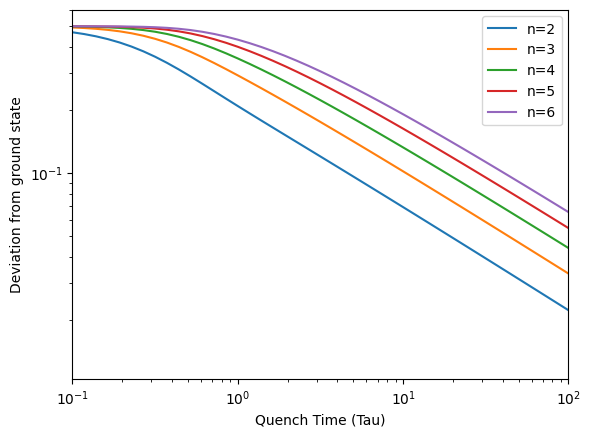

In [147]:
for n in range(1,6):
    X =np.abs(np.array(dat1).T[:,n])

    plt.plot(T,X,label=rf"n={n+1}")
#plt.plot(T,T**(-1/2),linestyle="--",color="black")
plt.yscale("log")
plt.xscale("log")
plt.legend()
#plt.ylim(0,0.5)
plt.xlim(T[0],100)
plt.xlabel("Quench Time (Tau)")
plt.ylabel("Deviation from ground state")

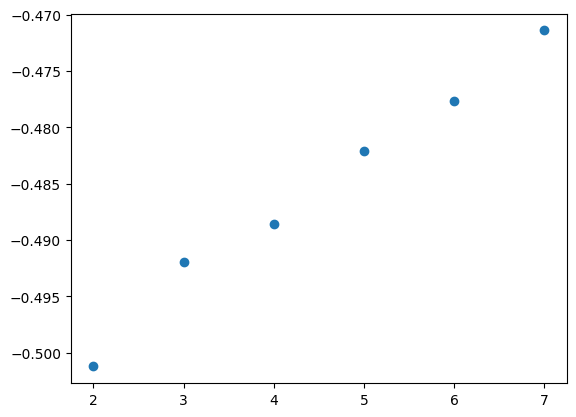

In [122]:
plt.scatter([2,3,4,5,6,7],d)

SOUVIK AND YOU TALKED ABOUT:

integrating the difference from the instananeous ground state over time (eg integral of delta(t) over time to tau)

making sure that you correctly get the LZ effect math correct. just double check plus you'd have to write this out anyways so its not a big effin deal

do this quickly so you can get feedback :D

np.float64(0.9891576)